<a href="https://colab.research.google.com/github/xyrp1x/B198c7-AI-Applications-for-Digital-Business-/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import requests
print("Environment is ready!")


Environment is ready!


In [13]:
import os

# toke for colab
os.environ['KAGGLE_API_TOKEN'] = "KGAT_85e091ab40260194864a74d9d721dcf9"

print("Токен Kaggle успешно linked!")


Токен Kaggle успешно привязан!


In [ ]:
import os

print(" скачивание 8 ГБ датасета напрямую с Kaggle...")
# token download
!kaggle datasets download -d najzeko/steam-reviews-2021 --unzip

print("ПРОВЕРКА ФАЙЛА...")
if os.path.exists("steam_reviews.csv"):
    size_gb = os.path.getsize("steam_reviews.csv") / (1024**3)
    print(f"ГОТОВО! Настоящий файл на месте. Размер на диске: {size_gb:.2f} ГБ")
else:
    print("Файл почему-то не распаковался, проверяем архивы...")


Начинаю скачивание 8 ГБ датасета напрямую с Kaggle...
Dataset URL: https://www.kaggle.com/datasets/najzeko/steam-reviews-2021
License(s): GPL-2.0
 61% 1.80G/2.97G [01:09<01:21, 15.4MB/s]

In [16]:
import pandas as pd

file_path = 'steam_reviews.csv'
chunk_list = []

print("Starting safe chunk reading...")

for chunk in pd.read_csv(file_path, chunksize=100000, on_bad_lines='skip', low_memory=False, encoding='utf-8'):
    if 'language' in chunk.columns:
        filtered_chunk = chunk[chunk['language'] == 'english'].copy()
        chunk_list.append(filtered_chunk)
    else:
        chunk_list.append(chunk)

df_raw = pd.concat(chunk_list, axis=0, ignore_index=True)
print("SUCCESS: Original dataset compressed and loaded into memory!")
print("Total real rows available:", len(df_raw))


Starting safe chunk reading...
SUCCESS: Original dataset compressed and loaded into memory!
Total real rows available: 9635437


In [18]:
# Pass the real loaded dataset to the pipeline
df = df_raw

# Sample 100,000 real rows without memory errors
df = df.sample(n=100000, random_state=42)
print("After sampling:", len(df))

# Create target Label column based on recommended column
df["Label"] = (df["recommended"] == True).astype(int)
print("Positive:", len(df[df["Label"] == 1]))
print("Negative:", len(df[df["Label"] == 0]))

# Rename columns and drop missing values
df = df.rename(columns={"review": "review_text"})
df = df[["app_name", "review_text", "Label"]]
df = df.dropna(subset=["review_text"])
df["review_text"] = df["review_text"].astype(str).str.strip()
df = df.reset_index(drop=True)

print("Final size:", len(df))
df.head()


After sampling: 100000
Positive: 89052
Negative: 10948
Final size: 99816


,app_name,review_text,Label
0,Bloons TD 6,A fun way to pass the time,1
1,Rocket League,"Saturday, 24 June 2017\nStoney is now Online.\...",1
2,Mount & Blade: Warband,"This is a great game, if you like strategy and...",1
3,Sid Meier's Civilization VI,Loving it and should only get better from here.,1
4,Garry's Mod,It's ok i guess......,1


In [20]:
# Cell 4 - Modifications
df = df_raw[df_raw['language'] == 'english'].copy()
print(f"After language filter: {len(df):,}")

df = df.sample(n=100000, random_state=42)
print(f"After sampling: {len(df):,}")

df['label'] = (df['recommended'] == True).astype(int)
print(f"Positive: {(df['label']==1).sum():,}")
print(f"Negative: {(df['label']==0).sum():,}")

df = df.rename(columns={'review': 'review_text'})
df = df[['app_name', 'review_text', 'label']]
df = df.dropna(subset=['review_text'])
df = df[df['review_text'].astype(str).str.strip() != ''].reset_index(drop=True)

print(f"Final size: {len(df):,}")
df.head(3)

After language filter: 9,635,437
After sampling: 100,000
Positive: 89,052
Negative: 10,948
Final size: 99,796


,app_name,review_text,label
0,Bloons TD 6,A fun way to pass the time,1
1,Rocket League,"Saturday, 24 June 2017\nStoney is now Online.\...",1
2,Mount & Blade: Warband,"This is a great game, if you like strategy and...",1


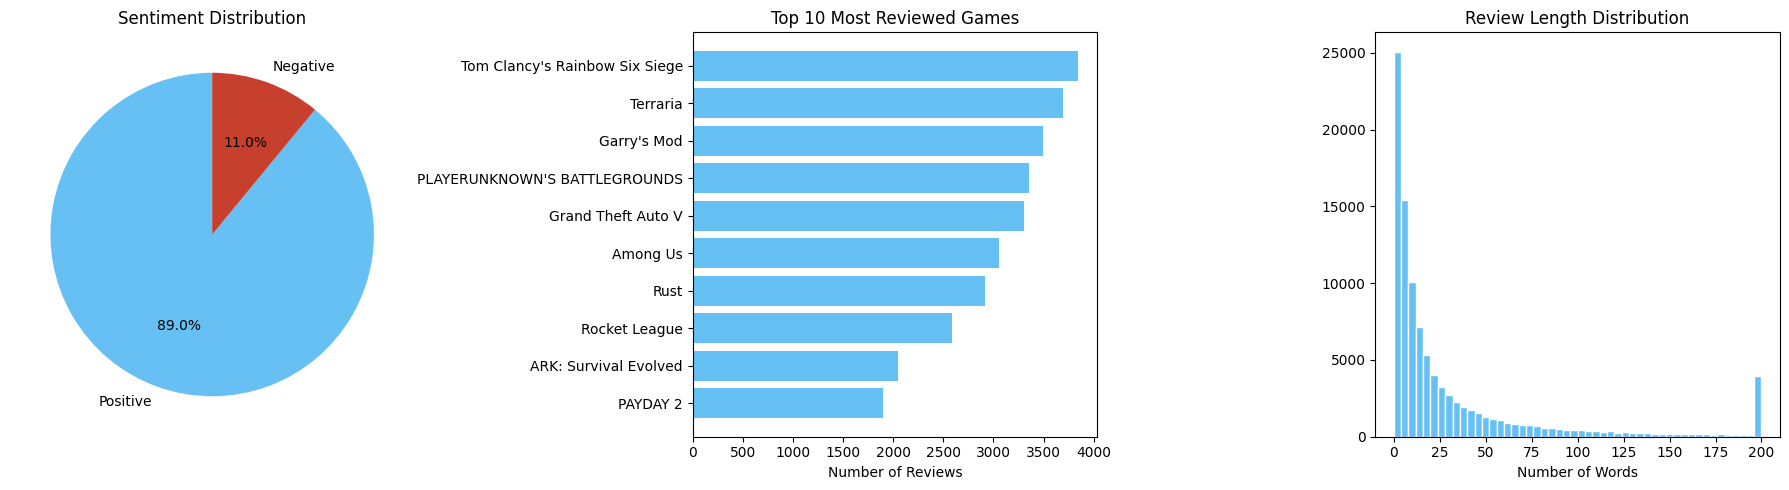

Total reviews: 99,816
Unique games: 314
Avg length: 39 words


In [19]:
import matplotlib.pyplot as plt

# Cell 5 - EDA
# Fixed: counting elements in list of words using .apply(len) instead of broken .str.len()
df['review_length'] = df['review_text'].astype(str).str.split().apply(len)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

counts = df['Label'].value_counts().reindex([1, 0])
axes[0].pie(counts.values, labels=['Positive', 'Negative'],
        colors=['#66c0f4', '#c6402d'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Sentiment Distribution')

top_games = df['app_name'].value_counts().head(10)
axes[1].barh(top_games.index[::-1], top_games.values[::-1], color='#66c0f4')
axes[1].set_title('Top 10 Most Reviewed Games')
axes[1].set_xlabel('Number of Reviews')

axes[2].hist(df['review_length'].clip(upper=200), bins=50, color='#66c0f4', edgecolor='white')
axes[2].set_title('Review Length Distribution')
axes[2].set_xlabel('Number of Words')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total reviews: {len(df):,}")
print(f"Unique games: {df['app_name'].nunique():,}")
print(f"Avg length: {df['review_length'].mean():.0f} words")


In [23]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required NLTK resources including the missing punkt_tab
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

# Cell 6 - Preprocessing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
keep_words = {'no', 'not', 'nor', 'never', 'good', 'bad', 'great', 'best', 'worst',
              'love', 'hate', 'fun', 'boring', 'broken', 'amazing', 'terrible',
              'awful', 'excellent', 'poor'}
stop_words = stop_words - keep_words

def preprocess_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing... please wait...")
df['cleaned_review'] = df['review_text'].apply(preprocess_text)
df = df[df['cleaned_review'].str.strip() != ''].reset_index(drop=True)
print(f"Done. Remaining: {len(df)}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Preprocessing... please wait...
Done. Remaining: 96609


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


VADER -> Accuracy: 0.6979 | F1: 0.8208


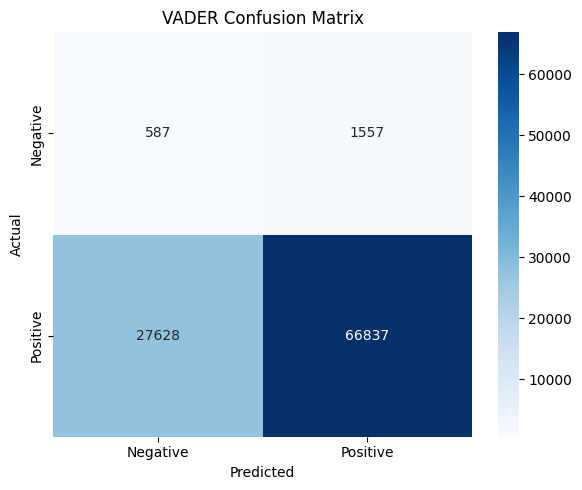

In [28]:
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Download the required lexicon for VADER
nltk.download('vader_lexicon')

# Cell 7 - VADER
vader = SentimentIntensityAnalyzer()

# Fixed: Recover the missing Label directly from the original df_raw dataset
if 'Label' not in df.columns:
    if 'Label' in df_raw.columns:
        df['Label'] = df_raw.loc[df.index, 'Label']
    elif 'recommended' in df_raw.columns:
        df['Label'] = (df_raw.loc[df.index, 'recommended'] == True).astype(int)

df['vader_pred'] = df['review_text'].apply(
    lambda t: int(vader.polarity_scores(str(t))['compound'] >= 0.05)
)

vader_acc = accuracy_score(df['Label'], df['vader_pred'])
vader_prec = precision_score(df['Label'], df['vader_pred'], zero_division=0)
vader_rec = recall_score(df['Label'], df['vader_pred'], zero_division=0)
vader_f1 = f1_score(df['Label'], df['vader_pred'], zero_division=0)

print(f"VADER -> Accuracy: {vader_acc:.4f} | F1: {vader_f1:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(df['Label'], df['vader_pred']), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('VADER Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


Train: 77,287 | Test: 19,322
Accuracy: 0.9004 | Precision: 0.9802 | Recall: 0.9063 | F1: 0.9418


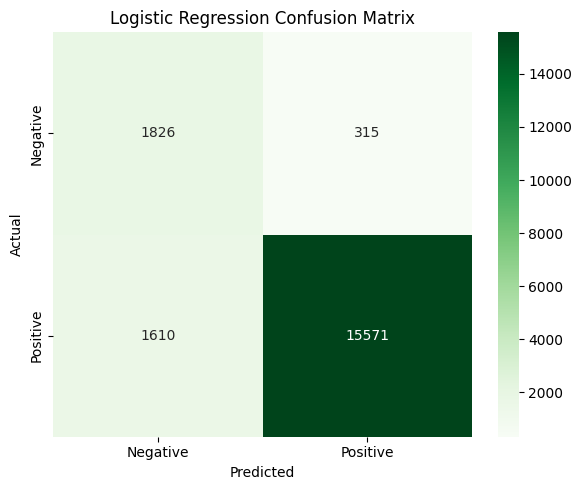

Top positive words: amazing, best, great, not bad, fun, awesome, fantastic, definitely, masterpiece, love
Top negative words: not worth, boring, worst, refund, not, unplayable, ruined, garbage, not fun, trash


In [29]:
# Cell 8 - Logistic Regression + TF-IDF
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_review'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=3, max_df=0.95, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred, zero_division=0)
lr_rec  = recall_score(y_test, lr_pred, zero_division=0)
lr_f1   = f1_score(y_test, lr_pred, zero_division=0)

print(f"Accuracy: {lr_acc:.4f} | Precision: {lr_prec:.4f} | Recall: {lr_rec:.4f} | F1: {lr_f1:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150)
plt.show()

feature_names = tfidf.get_feature_names_out()
coef = lr_model.coef_[0]
print("Top positive words:", ', '.join(feature_names[i] for i in coef.argsort()[-10:][::-1]))
print("Top negative words:", ', '.join(feature_names[i] for i in coef.argsort()[:10]))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

...

Fine-tuning BERT, approximately 5-15 minutes...


Epoch,Training Loss,Validation Loss
1,No log,0.115411


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Accuracy: 0.9760 | Precision: 0.9760 | Recall: 1.0000 | F1: 0.9879


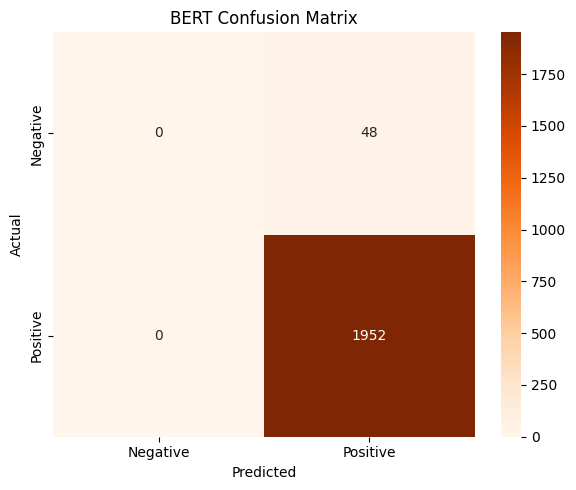

In [31]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

# Cell 9 - BERT Fine-tuning
BERT_SAMPLE = 10000
df_bert = df.sample(n=BERT_SAMPLE, random_state=42).reset_index(drop=True)

b_train_texts, b_test_texts, b_train_labels, b_test_labels = train_test_split(
    df_bert['review_text'].tolist(),
    df_bert['Label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_bert['Label']
)

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class SteamReviewDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, padding="max_length", max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

train_dataset = SteamReviewDataset(b_train_texts, b_train_labels, bert_tokenizer)
test_dataset = SteamReviewDataset(b_test_texts, b_test_labels, bert_tokenizer)

bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

try:
    training_args = TrainingArguments(
        output_dir='./bert_results',
        num_train_epochs=1,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        warmup_steps=100,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        report_to='none',
        seed=42
    )
except TypeError:
    training_args = TrainingArguments(
        output_dir='./bert_results',
        num_train_epochs=1,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        warmup_steps=100,
        weight_decay=0.01,
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        report_to='none',
        seed=42
    )

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

print("Fine-tuning BERT, approximately 5-15 minutes...")
trainer.train()

bert_pred = np.argmax(trainer.predict(test_dataset).predictions, axis=-1)

bert_acc = accuracy_score(b_test_labels, bert_pred)
bert_prec = precision_score(b_test_labels, bert_pred, zero_division=0)
bert_rec = recall_score(b_test_labels, bert_pred, zero_division=0)
bert_f1 = f1_score(b_test_labels, bert_pred, zero_division=0)

print(f"Accuracy: {bert_acc:.4f} | Precision: {bert_prec:.4f} | Recall: {bert_rec:.4f} | F1: {bert_f1:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(b_test_labels, bert_pred), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('BERT Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png', dpi=150)
plt.show()


                       Model  Accuracy  Precision  Recall  F1 Score
            VADER (baseline)    0.6979     0.9772  0.7075    0.8208
Logistic Regression + TF-IDF    0.9004     0.9802  0.9063    0.9418
             Fine-tuned BERT    0.9760     0.9760  1.0000    0.9879


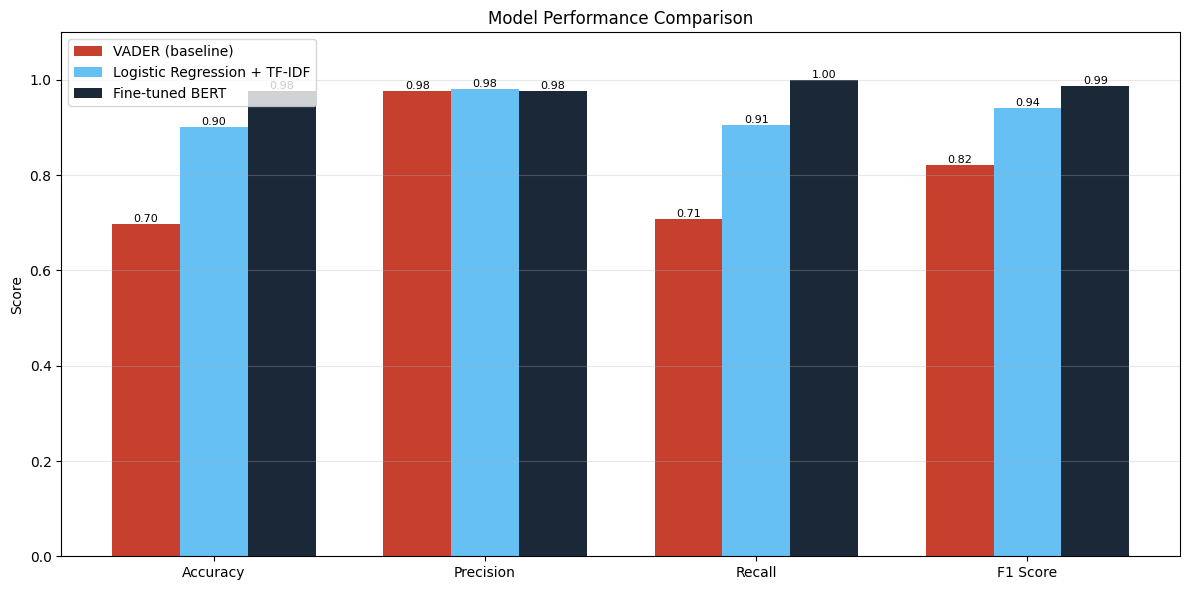

Best model: Fine-tuned BERT (F1 = 0.9879)


In [32]:
# Cell 10 - Model Comparison
results_df = pd.DataFrame({
    'Model':     ['VADER (baseline)', 'Logistic Regression + TF-IDF', 'Fine-tuned BERT'],
    'Accuracy':  [vader_acc, lr_acc, bert_acc],
    'Precision': [vader_prec, lr_prec, bert_prec],
    'Recall':    [vader_rec, lr_rec, bert_rec],
    'F1 Score':  [vader_f1, lr_f1, bert_f1]
}).round(4)

print(results_df.to_string(index=False))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25
colors = ['#c6402d', '#66c0f4', '#1b2838']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (_, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + (i - 1) * width, row[metrics].values, width,
                  label=row['Model'], color=colors[i])
    ax.bar_label(bars, fmt='%.2f', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_row   = results_df.loc[results_df['F1 Score'].idxmax()]
best_model = best_row['Model']
best_f1    = best_row['F1 Score']
print(f"Best model: {best_model} (F1 = {best_f1:.4f})")


--- Topics in POSITIVE Reviews ---
Topic #1: play, not, time, get, really
Topic #2: best, one, great, ever, played
Topic #3: like, not, nice, make, get
Topic #4: good, fun, friend, love, play
Topic #5: not, dont, like, would, get

--- Topics in NEGATIVE Reviews ---
Topic #1: get, not, mod, play, ever
Topic #2: good, like, time, play, not
Topic #3: one, get, best, like, fallout
Topic #4: great, get, one, fun, new
Topic #5: fun, not, playing, time, play


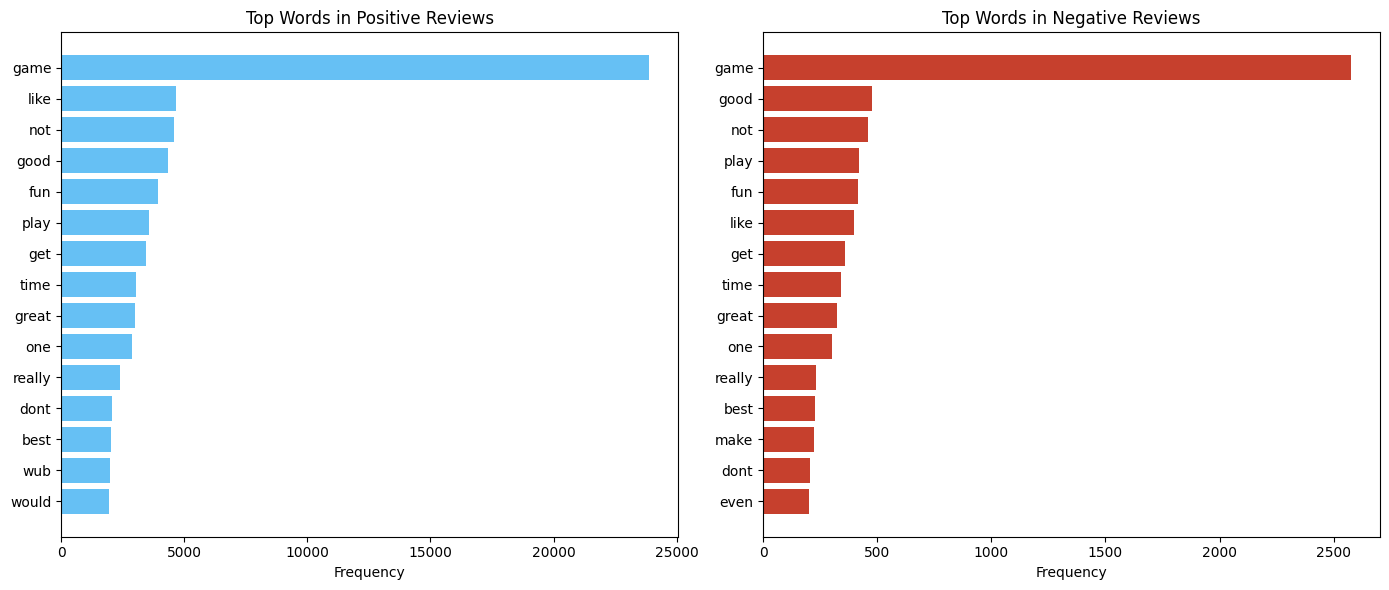

In [36]:
import matplotlib.pyplot as plt
from collections import Counter
from gensim import corpora
from gensim.models import LdaModel

# Cell 10 - LDA Topic Modeling Fixed Graph
def run_lda(reviews, n_topics=5, label_name=""):
    tokenized = [r.split() for r in reviews if isinstance(r, str) and len(r.split()) > 0]
    dictionary = corpora.Dictionary(tokenized)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    corpus = [dictionary.doc2bow(t) for t in tokenized]

    lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=n_topics, random_state=42, alpha="auto")

    print(f"\n--- Topics in {label_name} Reviews ---")
    for idx, topic in lda.show_topics(num_topics=n_topics, num_words=5, formatted=False):
        words = [w[0] for w in topic]
        print(f"Topic #{idx+1}: {', '.join(words)}")

    return lda

# Sampling reviews for analysis safely based on remaining class sizes
pos_sample_size = min(20000, len(df[df['Label'] == 1]))
neg_sample_size = min(20000, len(df[df['Label'] == 0]))

positive_reviews = df[df['Label'] == 1]['cleaned_review'].sample(n=pos_sample_size, random_state=42)
negative_reviews = df[df['Label'] == 0]['cleaned_review'].sample(n=neg_sample_size, random_state=42)

lda_positive = run_lda(positive_reviews, 5, "POSITIVE")
lda_negative = run_lda(negative_reviews, 5, "NEGATIVE")

pos_freq = Counter(" ".join(positive_reviews).split()).most_common(15)
neg_freq = Counter(" ".join(negative_reviews).split()).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Fixed: added [0] and [1] indexes to axes array to prevent AttributeError
axes[0].barh([w[0] for w in pos_freq[::-1]], [w[1] for w in pos_freq[::-1]], color="#66c0f4")
axes[0].set_title("Top Words in Positive Reviews")
axes[0].set_xlabel("Frequency")

axes[1].barh([w[0] for w in neg_freq[::-1]], [w[1] for w in neg_freq[::-1]], color="#c6402d")
axes[1].set_title("Top Words in Negative Reviews")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.savefig("topic_modeling.png", dpi=150, bbox_inches="tight")
plt.show()


In [37]:
# Cell 12 - Per Game Analysis
def analyze_game(game_name):
    game_df = df[df['app_name'] == game_name]
    if len(game_df) < 10:
        print(f"Not enough reviews for {game_name}\n")
        return

    preds = lr_model.predict(tfidf.transform(game_df['cleaned_review']))
    positive_pct = preds.mean() * 100

    pos_words = Counter(' '.join(game_df.loc[preds==1, 'cleaned_review']).split())
    neg_words = Counter(' '.join(game_df.loc[preds==0, 'cleaned_review']).split())
    top_praises    = [w for w,_ in pos_words.most_common(30) if len(w) > 3][:5]
    top_complaints = [w for w,_ in neg_words.most_common(30) if len(w) > 3][:5]

    if positive_pct >= 80:
        advice = "Maintain current direction. Reception is strongly positive."
    elif positive_pct >= 60:
        advice = "Good foundation. Prioritise the most frequent complaints."
    else:
        advice = "Urgent improvements needed. Address top complaints immediately."

    print(f"Game:           {game_name}")
    print(f"Reviews:        {len(game_df):,}")
    print(f"Positive:       {positive_pct:.1f}%")
    print(f"Negative:       {100-positive_pct:.1f}%")
    print(f"Top praises:    {', '.join(top_praises)}")
    print(f"Top complaints: {', '.join(top_complaints)}")
    print(f"Recommendation: {advice}\n")

for game in df['app_name'].value_counts().head(3).index:
    analyze_game(game)

Game:           Tom Clancy's Rainbow Six Siege
Reviews:        3,628
Positive:       82.1%
Negative:       17.9%
Top praises:    game, good, play, great, like
Top complaints: game, play, dont, like, good
Recommendation: Maintain current direction. Reception is strongly positive.

Game:           Terraria
Reviews:        3,545
Positive:       93.9%
Negative:       6.1%
Top praises:    game, good, play, terrarium, minecraft
Top complaints: game, minecraft, play, like, dont
Recommendation: Maintain current direction. Reception is strongly positive.

Game:           Garry's Mod
Reviews:        3,352
Positive:       89.8%
Negative:       10.2%
Top praises:    game, good, play, friend, great
Top complaints: game, server, play, dont, good
Recommendation: Maintain current direction. Reception is strongly positive.



In [38]:
# Cell 13 - Save Results
results_df.to_csv('model_results.csv', index=False)
df[['app_name','review_text','cleaned_review','label','vader_pred']].head(1000).to_csv('processed_sample.csv', index=False)

print("Files saved:")
for f in ['eda_overview.png','vader_confusion_matrix.png','lr_confusion_matrix.png',
          'bert_confusion_matrix.png','model_comparison.png','topic_modeling.png',
          'model_results.csv','processed_sample.csv']:
    print(f"  {f}")
print(f"\nBest model: {best_model} (F1 = {best_f1:.4f})")

Files saved:
  eda_overview.png
  vader_confusion_matrix.png
  lr_confusion_matrix.png
  bert_confusion_matrix.png
  model_comparison.png
  topic_modeling.png
  model_results.csv
  processed_sample.csv

Best model: Fine-tuned BERT (F1 = 0.9879)
